In [ ]:
# importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Data Loading

In [3]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


Data Details

In [4]:
train = pd.read_csv("train.csv")

In [5]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [6]:
train.shape

(3000888, 6)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


Convert date

In [9]:
train['date'] = pd.to_datetime(train['date'])

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


Checking for date range

In [10]:
print("Start date:", train['date'].min())
print("End date:", train['date'].max())

Start date: 2013-01-01 00:00:00
End date: 2017-08-15 00:00:00


how many stores and product families

In [11]:
print("Number of stores:", train['store_nbr'].nunique())
print("Number of product families:", train['family'].nunique())

Number of stores: 54
Number of product families: 33


In [12]:
print(train['family'].unique())

['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


##Data Cleaning

Check duplicate rows

In [13]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


Checking Missing Values

In [14]:
print(train.isnull().sum())

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


Checking DataTypes

In [15]:
print(train.dtypes)

id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object


Check for invalid sales values

In [16]:
print("Negative sales:", (train['sales'] < 0).sum())

Negative sales: 0


check  for promotion values

In [17]:
print("Negative promotions:", (train['onpromotion'] < 0).sum())

Negative promotions: 0


Checking for Unique IDs

In [18]:
print("Unique IDs:", train['id'].nunique())
print("Total rows:", len(train))

Unique IDs: 3000888
Total rows: 3000888


Check whether the categorical values are reasonable

In [19]:
print("Stores:", train['store_nbr'].nunique())
print("Product families:", train['family'].nunique())

Stores: 54
Product families: 33


Copy of clean data

In [20]:
clean_train = train.copy()

Saving clean dataset in drive for record

In [25]:
import os

save_path = '/content/drive/MyDrive/'
os.makedirs(save_path, exist_ok=True)

clean_train.to_csv(
    f'{save_path}/clean_train.csv',
    index=False
)

print("Clean dataset saved successfully!")
print(f"Location: {save_path}/clean_train.csv")

Clean dataset saved successfully!
Location: /content/drive/MyDrive/EncoderX_Sales_Project/clean_train.csv


Create the date features

In [21]:
clean_train = train.copy()

clean_train['year'] = clean_train['date'].dt.year
clean_train['month'] = clean_train['date'].dt.month
clean_train['day'] = clean_train['date'].dt.day
clean_train['day_of_week'] = clean_train['date'].dt.dayofweek
clean_train['is_weekend'] = clean_train['day_of_week'].isin([5, 6]).astype(int)

clean_train.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,day_of_week,is_weekend
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1,0
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1,0


Check

In [22]:
clean_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 11 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
 6   year         int32         
 7   month        int32         
 8   day          int32         
 9   day_of_week  int32         
 10  is_weekend   int64         
dtypes: datetime64[ns](1), float64(1), int32(4), int64(4), object(1)
memory usage: 206.1+ MB


Check for Negative Sale values

In [23]:
print("Negative sales:", (clean_train['sales'] < 0).sum())
print("Negative promotions:", (clean_train['onpromotion'] < 0).sum())

Negative sales: 0
Negative promotions: 0


##EDA(Exploratory Data Analysis)

Total sales by year

In [26]:
yearly_sales = clean_train.groupby('year')['sales'].sum()

print(yearly_sales)

year
2013    1.404190e+08
2014    2.094742e+08
2015    2.408801e+08
2016    2.886545e+08
2017    1.942171e+08
Name: sales, dtype: float64


Visualization

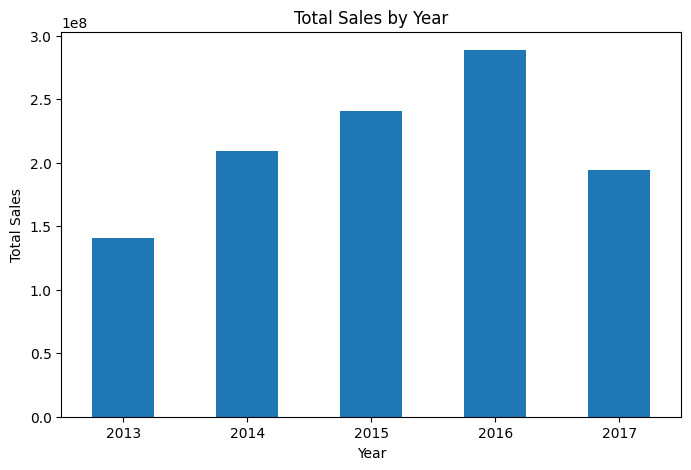

In [27]:
plt.figure(figsize=(8, 5))

yearly_sales.plot(kind='bar')

plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

Total sales by product family

In [28]:
family_sales = (
    clean_train.groupby('family')['sales']
    .sum()
    .sort_values(ascending=False)
)

print(family_sales)

family
GROCERY I                     3.434627e+08
BEVERAGES                     2.169545e+08
PRODUCE                       1.227047e+08
CLEANING                      9.752129e+07
DAIRY                         6.448771e+07
BREAD/BAKERY                  4.213395e+07
POULTRY                       3.187600e+07
MEATS                         3.108647e+07
PERSONAL CARE                 2.459205e+07
DELI                          2.411032e+07
HOME CARE                     1.602274e+07
EGGS                          1.558830e+07
FROZEN FOODS                  1.407389e+07
PREPARED FOODS                8.799895e+06
LIQUOR,WINE,BEER              7.746640e+06
SEAFOOD                       2.015432e+06
GROCERY II                    1.962767e+06
HOME AND KITCHEN I            1.861491e+06
HOME AND KITCHEN II           1.520670e+06
CELEBRATION                   7.611770e+05
LINGERIE                      6.531140e+05
LADIESWEAR                    6.511590e+05
PLAYERS AND ELECTRONICS       5.626080e+05
AUTO

Visualize

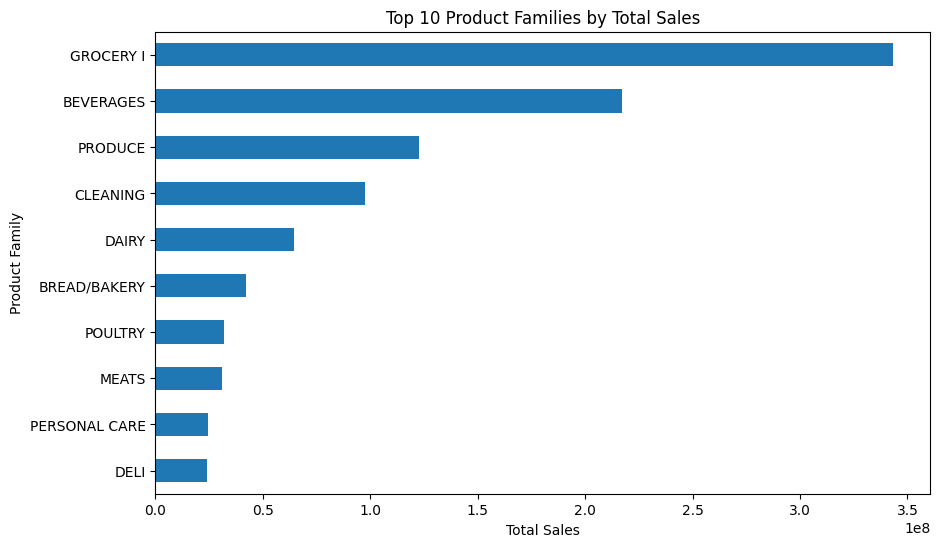

In [29]:
plt.figure(figsize=(10, 6))

family_sales.head(10).plot(kind='barh')

plt.title('Top 10 Product Families by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Family')
plt.gca().invert_yaxis()

plt.show()

##These two analyses answer two basic business questions:

###How have sales changed over the years?

Sales increased steadily from 140.4M (2013) to 288.7M (2016). 2017 has 194.2M, but it only includes data until August.




###Which product categories generate the most sales?

GROCERY I has the highest sales (343.5M), followed by BEVERAGES (217.0M) and PRODUCE (122.7M).